<a href="https://colab.research.google.com/github/erdijova/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_7_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Unsupervised Learning

This chapter focuses on methods used to uncover hidden patterns in data without labeled outcomes.

Unlike supervised learning, unsupervised learning explores structure and relationships within the data.

### Overview

Unsupervised learning techniques are used when there is no target variable.

**Key Ideas:**
- Discover patterns in data
- Reduce dimensionality
- Group similar observations

Main methods covered:
- Principal Component Analysis (PCA)
- K-Means Clustering
- Hierarchical Clustering

### Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage


### Load Dataset

We use a dataset to demonstrate clustering and dimensionality reduction.

In [2]:

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Data Preparation

Unsupervised methods often require scaling to ensure all variables contribute equally.

In [3]:

X = df.drop('species', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Principal Component Analysis (PCA)

PCA reduces dimensionality by transforming data into new components.

**Key Ideas:**
- Captures maximum variance
- Reduces complexity
- Helps visualization

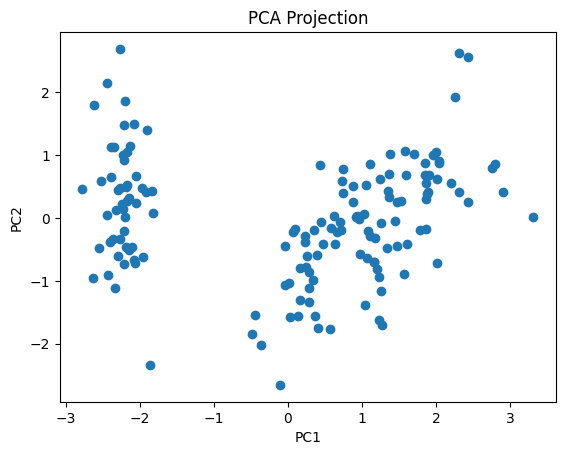

In [4]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Explained Variance

Shows how much information is retained by each component.

In [5]:

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.72962445 0.22850762]


### K-Means Clustering

K-Means groups data into K clusters.

**Algorithm steps:**
1. Initialize centroids
2. Assign points to clusters
3. Update centroids
4. Repeat until convergence

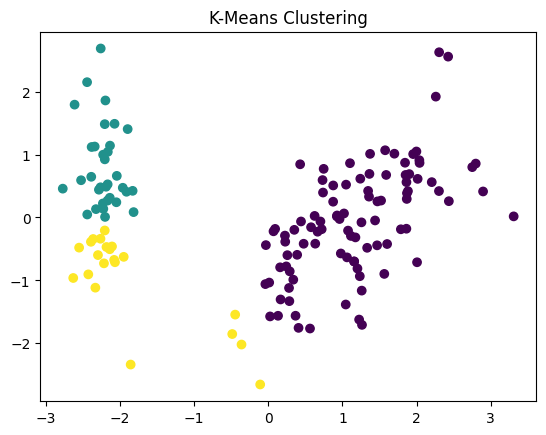

In [6]:

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("K-Means Clustering")
plt.show()


### Choosing K (Elbow Method)

Helps determine optimal number of clusters.

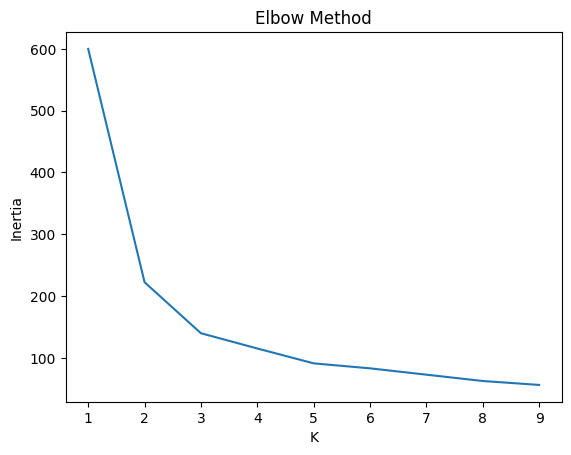

In [7]:

inertia = []
k_range = range(1,10)

for k in k_range:
    model = KMeans(n_clusters=k)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


### Hierarchical Clustering

Builds nested clusters using a tree structure.

**Key Ideas:**
- Does not require predefined K
- Uses distance metrics

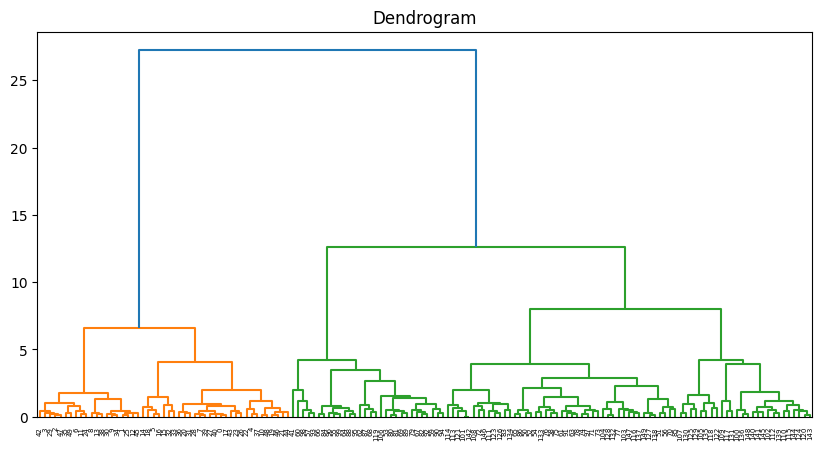

In [8]:

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()


### Conclusion

In this chapter, we explored:
- PCA for dimensionality reduction
- K-Means clustering
- Hierarchical clustering

Unsupervised learning helps uncover hidden structures in data.